In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

# Data Generation

In [2]:
def add_noise(y_base, low=0, high=0.2):
  # Random signs (-1 or 1)
  signs = torch.where(torch.rand(y_base.shape) > 0.5, 1.0, -1.0)

  # Random scale within bounds
  scales = torch.rand(y_base.shape) * (high - low) + low

  return signs * scales * y_base

SSR: 123.9533


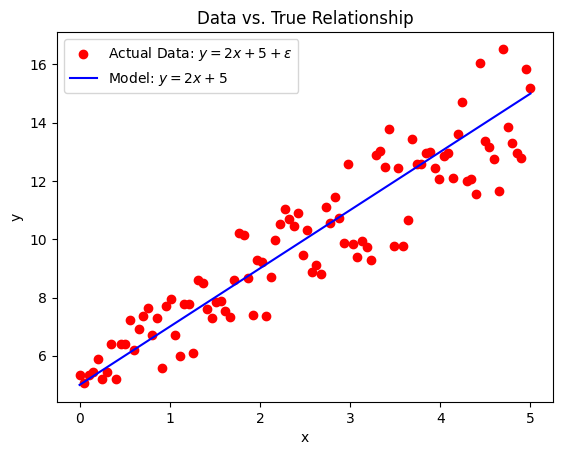

In [3]:
_ = torch.manual_seed(5)
x = torch.linspace(0, 5, 100)

# Underlying true relationship: y = 2x + 5
true_beta1 = 2
true_beta0 = 5

# Add Noise (ε)
y_base = true_beta1 * x + true_beta0
noise = add_noise(y_base)
y = y_base + noise

# Model Prediction (using known parameters)
y_pred = true_beta1 * x + true_beta0
ssr = torch.sum((y - y_pred) ** 2)
print(f"SSR: {ssr:.4f}")

# Plotting
_ = plt.scatter(x, y, color='red', label=r'Actual Data: $y = 2x + 5 + \epsilon$')
_ = plt.plot(x, y_pred, label=f'Model: $y = {true_beta1}x + {true_beta0}$', color='blue')
_ = plt.title('Data vs. True Relationship')
_ = plt.xlabel('x')
_ = plt.ylabel('y')
_ = plt.legend()

# Analytical Best Fit

SSR: 114.5550
Learned Equation: y = 1.81x + 5.35


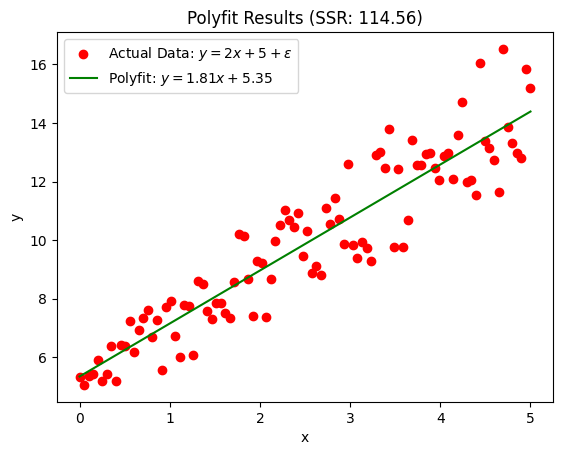

In [4]:
# Model Training
# deg=1 for linear regression (y = mx + b)
m, b = np.polyfit(x, y, deg=1)

# Prediction & Metrics
y_pred = m * x + b
ssr = torch.sum((y - y_pred) ** 2)
print(f"SSR: {ssr:.4f}")
print(f"Learned Equation: y = {m:.2f}x + {b:.2f}")

# Plotting
_ = plt.scatter(x, y, color='red', label=r'Actual Data: $y = 2x + 5 + \epsilon$')
_ = plt.plot(x, y_pred, color='green', label=f'Polyfit: $y = {m:.2f}x + {b:.2f}$')
_ = plt.title(f'Polyfit Results (SSR: {ssr:.2f})')
_ = plt.xlabel('x')
_ = plt.ylabel('y')
_ = plt.legend()

# Moving on to **Gradient Descent**

In [5]:
X = x.reshape(-1, 1)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: torch.Size([100, 1])
y shape: torch.Size([100])


# Train test splitting

X_train shape: torch.Size([80, 1]), y_train shape: torch.Size([80])
X_test shape: torch.Size([20, 1]), y_test shape: torch.Size([20])


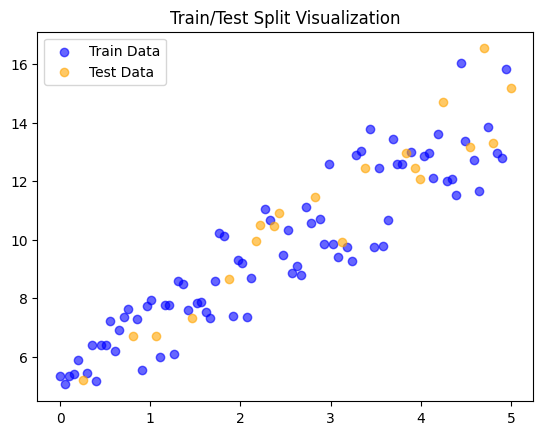

In [6]:
train_size = int(len(X) * 0.8)
test_size = len(X) - train_size

indices = torch.randperm(len(X))
train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train, X_test = X[train_indices], X[test_indices]
y_train, y_test = y[train_indices], y[test_indices]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Visualize the split to ensure coverage
_ = plt.scatter(X_train, y_train, color='blue', label='Train Data', alpha=0.6)
_ = plt.scatter(X_test, y_test, color='orange', label='Test Data', alpha=0.6)
_ = plt.legend()
_ = plt.title("Train/Test Split Visualization")

# Data Loading Strategy

In [7]:
batch_size = 16

# Datasets
train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

# DataLoaders
# Shuffling the training data is crucial for Gradient Descent
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

# Shuffling test data isn't necessary, but we keep batching for consistency
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

# Quick check on a single batch
features, targets = next(iter(train_loader))
print(f"Batch features shape: {features.shape}")
print(f"Batch targets shape: {targets.shape}")

Batch features shape: torch.Size([16, 1])
Batch targets shape: torch.Size([16])


# Model Construction

In [8]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()

    # Initialize weights (ß1) and bias (ß0) with random values
    # We use nn.Parameter so PyTorch knows to track these for gradient descent
    self.weights = nn.Parameter(torch.randn(1, requires_grad=True))
    self.bias = nn.Parameter(torch.randn(1, requires_grad=True))

  def forward(self, x):
    # The forward pass: y = mx + b
    return self.weights * x + self.bias

In [10]:
_ = torch.manual_seed(42)
model = LinearRegressionModel()
model

LinearRegressionModel()

In [11]:
print("Initial Parameters:")
for name, param in model.named_parameters():
  print(f'{name}')
  print(f'{param}\n')

Initial Parameters:
weights
Parameter containing:
tensor([0.3367], requires_grad=True)

bias
Parameter containing:
tensor([0.1288], requires_grad=True)



In [12]:
with torch.no_grad():  # same as torch.inference_mode()
  y_pred = model(X_test)

((y_test - y_pred)**2).sum()  # SSR
((y_test - y_pred)**2).mean()  # MSE

tensor(42842.5664)

tensor(107.1064)

# Custom Loss Construction

In [13]:
class MeanSquaredError(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, y_pred, y_true):
    return torch.mean((y_pred - y_true) ** 2)  # MSE

In [14]:
mse_loss = MeanSquaredError()

# Create dummy tensors to test
y_true = torch.tensor([1.0, 2.0, 3.0])
y_pred = torch.tensor([1.5, 2.5, 3.5])

loss = mse_loss(y_pred, y_true)
print(f"Calculated Loss: {loss.item():.4f}")

Calculated Loss: 0.2500


# Initial Test Loss

Initial Test Loss: 107.1064


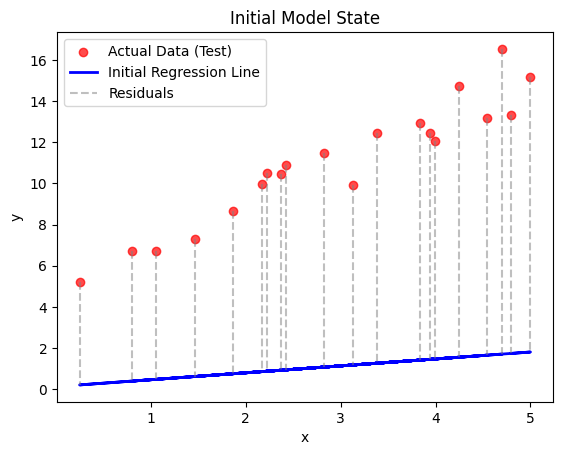

In [15]:
with torch.inference_mode():
  y_test_pred = model(X_test)
  initial_loss = mse_loss(y_test_pred, y_test)

print(f"Initial Test Loss: {initial_loss.item():.4f}")

# Actual Test Data
_ = plt.scatter(X_test, y_test, color='red', label='Actual Data (Test)', alpha=0.7)

# Model Prediction Line
_ = plt.plot(X_test, y_test_pred, color='blue', label='Initial Regression Line',
             linewidth=2)

# Residuals
_ = plt.vlines(X_test, y_test, y_test_pred, color='gray',
               linestyle='--', alpha=0.5, label='Residuals')
_ = plt.title(f"Initial Model State")
_ = plt.xlabel("x")
_ = plt.ylabel("y")
_ = plt.legend()

# Model Training and Optimization

In [16]:
learning_rate = 0.01

loss_fn = nn.MSELoss()
loss_fn

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
optimizer

MSELoss()

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

### The Training Loop

In [19]:
epochs = 100

# Initial loss
_ = model.eval()
with torch.inference_mode():
  initial_y_pred = model(X_train).squeeze()
  initial_loss = loss_fn(initial_y_pred, y_train)
  print(f"Initial Training Loss: {initial_loss.item():.4f}")
  print("-" * 30)

_ = model.train()

for epoch in range(1, epochs+1):
  for X_batch, y_batch in train_loader:
    # 1. forward pass
    y_pred = model(X_batch).squeeze()

    # 2. loss calculation
    loss = loss_fn(y_pred, y_batch)

    # 3. reset gradients
    optimizer.zero_grad()

    # 4. backward pass
    loss.backward()

    # 5. update params
    optimizer.step()

  if epoch % 10 == 0 or epoch == 1:
    print(f"Epoch: {epoch:3d} | Loss: {loss.item():.4f}")

Initial Training Loss: 1.1611
------------------------------
Epoch:   1 | Loss: 1.4024
Epoch:  10 | Loss: 1.5497
Epoch:  20 | Loss: 0.8881
Epoch:  30 | Loss: 1.1697
Epoch:  40 | Loss: 1.6683
Epoch:  50 | Loss: 1.7485
Epoch:  60 | Loss: 1.6451
Epoch:  70 | Loss: 1.2329
Epoch:  80 | Loss: 1.3848
Epoch:  90 | Loss: 2.1684
Epoch: 100 | Loss: 0.7705
